In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [42]:
df = pd.read_excel('P652-Dataset.xlsx')

In [43]:
df.head(20)

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."
5,Too much lagging and slow,1,I will never purchase Samsung phones. Phone is...
6,Worst samsung mobile ever,1,This is worst samsung mobile I have seen from ...
7,कैसा दिखाते है उसका 10 % भी नही,1,मोबाइल का कैमरा बिल्कुल भी सही नही है 48 PM बत...
8,Slow performance,1,The phone hangs a lot and is very slow. I rece...
9,Don’t buy from Amazon.,1,Very poor quality camera .Found box seal damag...


In [44]:
df.isna().sum()

,0
title,0
rating,0
body,0


In [45]:
df.duplicated().sum()

np.int64(0)

In [46]:
df.dtypes

,0
title,object
rating,int64
body,object


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [48]:
df['rating'].unique()

array([1, 3, 4, 5, 2])

In [49]:
df['rating'].value_counts()

,count
rating,
5,419
1,386
4,310
3,199
2,126


replacing 1,2 rating as 0(negative), 3 as neutral ;4 ,5
as 2 (positive)

In [50]:
df.replace({'rating':{1:0,2:0,3:1,4:2,5:2}}, inplace=True)

In [51]:
df_new = df['title'] + ' ' + df['body']

In [52]:
df_new= pd.concat([df_new, df['rating']], axis=1)

In [53]:
df_new.head()

,0,rating
0,Horrible product Very disappointed with the ov...,0
1,Camera quality is not like 48 megapixel Camera...,1
2,"Overall Got the mobile on the launch date,Batt...",2
3,A big no from me 1. It doesn't work with 5.0GH...,0
4,Put your money somewhere else Not worth buying...,0


In [54]:

df_new = df_new.rename(columns={0: 'Review'})

In [55]:

df_new.head()

,Review,rating
0,Horrible product Very disappointed with the ov...,0
1,Camera quality is not like 48 megapixel Camera...,1
2,"Overall Got the mobile on the launch date,Batt...",2
3,A big no from me 1. It doesn't work with 5.0GH...,0
4,Put your money somewhere else Not worth buying...,0


(np.float64(-0.5), np.float64(999.5), np.float64(599.5), np.float64(-0.5))

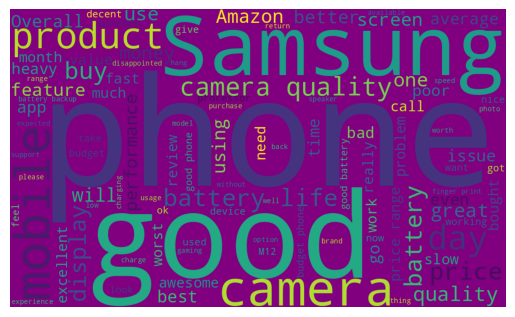

In [56]:
from wordcloud import WordCloud
wordcloud=WordCloud(width=1000,height=600,background_color='Purple',max_words=100).generate(df_new['Review'].str.cat(sep=' '))
plt.imshow(wordcloud)
plt.axis('off')

In [57]:
#Stopwords
import nltk
from nltk.corpus import stopwords
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_r

True

In [58]:
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer,WordNetLemmatizer

In [59]:
port=PorterStemmer()
def stemming(Review):
    stemmed_content = re.sub('[^a-zA-Z]',' ',Review)
    stemmed_content=stemmed_content.lower()
    stemmed_content=stemmed_content.split()
    stemmed_content=[port.stem(word) for word in stemmed_content if not word in stopwords.words('english')]
    stemmed_content=' '.join(stemmed_content)
    return stemmed_content

In [60]:
from nltk.corpus import stopwords
from collections import Counter # Import Counter

# Concatenate all reviews into a single string before splitting
all_reviews = df_new['Review'].str.cat(sep=' ')
# Split the combined text and filter out stopwords
tokens = [word for word in all_reviews.split() if word not in stopwords.words('english')]
word_counts = Counter(tokens)
top_words = word_counts.most_common(15)
top_words_df = pd.DataFrame(top_words, columns=['Word', 'Frequency'])

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'phone'),
  Text(1, 0, 'I'),
  Text(2, 0, 'good'),
  Text(3, 0, 'camera'),
  Text(4, 0, 'quality'),
  Text(5, 0, 'battery'),
  Text(6, 0, 'Samsung'),
  Text(7, 0, 'mobile'),
  Text(8, 0, 'The'),
  Text(9, 0, 'price'),
  Text(10, 0, 'buy'),
  Text(11, 0, 'product'),
  Text(12, 0, 'like'),
  Text(13, 0, 'also'),
  Text(14, 0, 'Camera')])

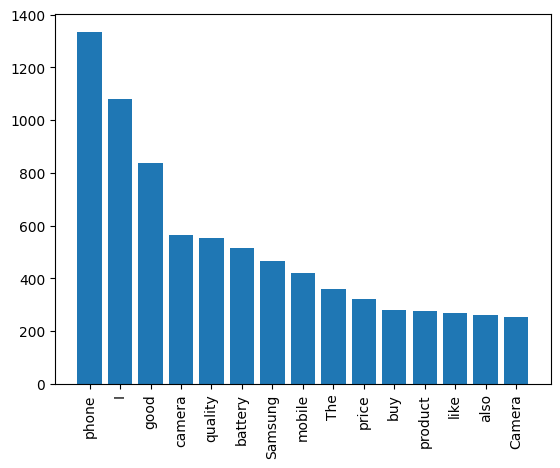

In [61]:
plt.bar(top_words_df['Word'],height=top_words_df['Frequency'])
plt.xticks(rotation=90)

In [62]:
df_new['stemmed_content']=df_new['Review'].apply(stemming)

In [63]:
df_new.head()

,Review,rating,stemmed_content
0,Horrible product Very disappointed with the ov...,0,horribl product disappoint overal perform samsung
1,Camera quality is not like 48 megapixel Camera...,1,camera qualiti like megapixel camera qualiti low
2,"Overall Got the mobile on the launch date,Batt...",2,overal got mobil launch date batteri must appr...
3,A big no from me 1. It doesn't work with 5.0GH...,0,big work ghz wifi frequenc ghz old school came...
4,Put your money somewhere else Not worth buying...,0,put money somewher els worth buy faulti softwa...


In [64]:
#Separating data and label
X=df_new['stemmed_content'].values
Y=df_new['rating'].values

In [65]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=50)

In [66]:
print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

(1152,) (1152,) (288,) (288,)


In [67]:
x_test

array(['decent smartphon price rang good batteri life fast charg option disabl uninstal pre instal app phone bit thick heavi hold tire hold long period time hz display nice adapt option avail set',
       'sturdi long last mobil sturdi phone good batteri storag rough tough use camera good good qualiti front back camera dimens good view video afford price make paisa vasool mobil',
       'batteri life awesom camera pathet want big batteri fast charg go pro awesom batteri lifefast chargingspeak loud crystal clearlik placement figur print sensercon pathet camera output even megapixel leveltoo heavi bulkydisplay averag',
       'low qualiti samsung fingerprint scanner slowtouchscreen respond timesne long press mani time get responsenetwork issu review use phone day total disappoint',
       'good batteri backup fast perform decent phone good batteri back day good usag design good hold hand screen good touch good camera ok type decent pic daylight howev artifici light averag overal decent b

In [68]:
#converting textual data into numerical form
from sklearn.feature_extraction.text import TfidfVectorizer
vectoriser = TfidfVectorizer(max_features=1000)
x_train=vectoriser.fit_transform(x_train)
x_test=vectoriser.transform(x_test)

In [69]:
print(x_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 27231 stored elements and shape (1152, 1000)>
  Coords	Values
  (0, 536)	0.27277352638376773
  (0, 621)	0.5965609861185683
  (0, 358)	0.18134684932724757
  (0, 471)	0.2860725624909228
  (0, 90)	0.21035472657818405
  (0, 387)	0.16296757884919977
  (0, 83)	0.16828915222941676
  (0, 124)	0.32912885050237184
  (0, 316)	0.24777072434292316
  (0, 700)	0.16828915222941676
  (0, 552)	0.18668812268878923
  (0, 909)	0.24180553999475585
  (0, 611)	0.16538720996347708
  (0, 564)	0.192727648481649
  (1, 984)	0.11090588071212282
  (1, 278)	0.15082245221760823
  (1, 757)	0.06967081603043433
  (1, 910)	0.1327363892298593
  (1, 291)	0.3541759865282288
  (1, 67)	0.10975858722202804
  (1, 432)	0.2003465924393344
  (1, 717)	0.21611759509232706
  (1, 378)	0.12104893522407949
  (1, 482)	0.3269651698546133
  (1, 929)	0.3242256004393194
  :	:
  (1151, 60)	0.10765962610312357
  (1151, 434)	0.10941611077209792
  (1151, 473)	0.08875471016489259
  (115

1.Logistic Regression

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model1=LogisticRegression(max_iter=1000)
model1.fit(x_train, y_train)
x_test_pred_lr =model1.predict(x_test)
Accuracy_score1=accuracy_score(y_test,x_test_pred_lr)
print("Logistic Regression Accuracy:",Accuracy_score1)

Logistic Regression Accuracy: 0.7881944444444444


2.Multinomial Naive Baye's

In [71]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

model2 = MultinomialNB()
model2.fit(x_train, y_train)
x_test_pred_mnb = model2.predict(x_test)
Accuracy_score2= accuracy_score(y_test, x_test_pred_mnb)
print("Multinomial Naive Bayes Accuracy:",Accuracy_score2)

Multinomial Naive Bayes Accuracy: 0.7673611111111112


3.Support Vector Machine

In [72]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

model3 = SVC()
model3.fit(x_train, y_train)
x_test_pred_svm = model3.predict(x_test)

Accuracy_score3 = accuracy_score(y_test, x_test_pred_svm)
print("Support Vector Machine Accuracy:", Accuracy_score3)

Support Vector Machine Accuracy: 0.7777777777777778


4.Random Forest

In [73]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model4 = RandomForestClassifier(random_state=50)
model4.fit(x_train, y_train)
x_test_pred_rf = model4.predict(x_test)

Accuracy_score4 = accuracy_score(y_test, x_test_pred_rf)
print("Random Forest Accuracy:", Accuracy_score4)

Random Forest Accuracy: 0.75


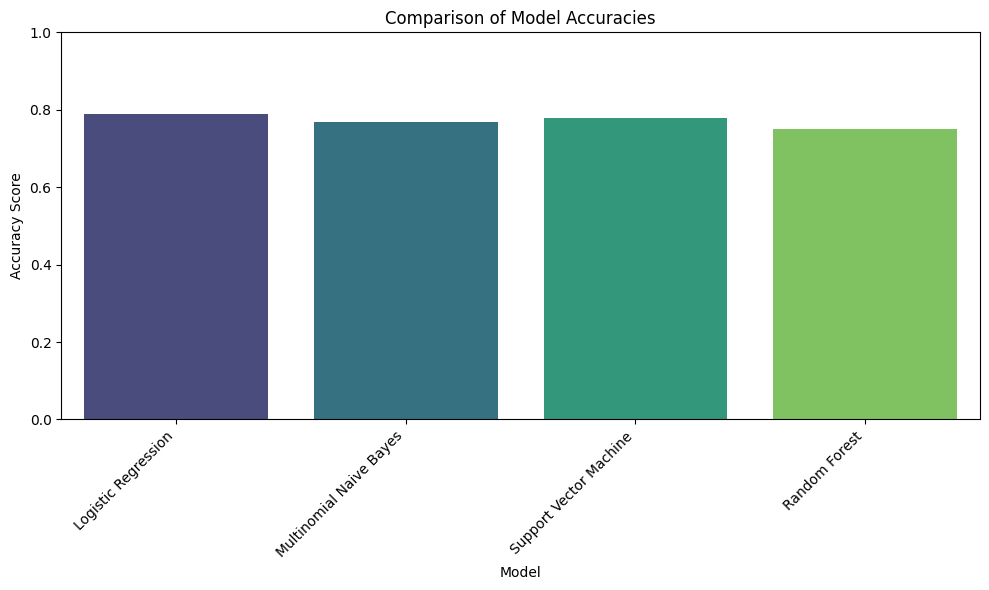

In [74]:
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import numpy as np

model_accuracies = {
    'Logistic Regression': Accuracy_score1,
    'Multinomial Naive Bayes': Accuracy_score2,
    'Support Vector Machine': Accuracy_score3,
    'Random Forest': Accuracy_score4
}

accuracies_df = pd.DataFrame(list(model_accuracies.items()), columns=['Model', 'Accuracy'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=accuracies_df, palette='viridis')
plt.title('Comparison of Model Accuracies')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1) # Set y-axis limits from 0 to 1
plt.yticks(np.arange(0, 1.01, 0.20)) # Set y-axis ticks from 0 to 1 with step 0.25
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [75]:
!pip install -q streamlit

In [76]:
!npm install -g localtunnel -U

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙
changed 22 packages in 5s
⠙
⠙3 packages are looking for funding
⠙  run `npm fund` for details
⠙

In [39]:
import pickle
file='log.pkl'

In [40]:
pickle.dump(model1,open(file,'wb'))

In [115]:
%%writefile Model_Dep_app.py
import streamlit as st
import pickle
log=pickle.load(open('log.pkl','rb'))
st.title("Sentiment Analysis")
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

port=PorterStemmer()
from sklearn.feature_extraction.text import TfidfVectorizer
vectoriser = TfidfVectorizer(max_features=1000)
def clean_log(text):
    stemmed_content = re.sub('[^a-zA-Z]',' ',text)
    stemmed_content=stemmed_content.lower()
    stemmed_content=stemmed_content.split()
    stemmed_content=[port.stem(word) for word in stemmed_content if not word in stopwords.words('english')]
    stemmed_content=' '.join(stemmed_content)
    return stemmed_content
st.write("Enter your review about the Product")
review_input = st.text_area("Review Text", height=150)

if st.button("Predict Sentiment"):
    if review_input.strip():
        # Processing steps
        cleaned_review = clean_log(review_input)
        vectorized_input = vectoriser.transform([cleaned_review])
        prediction = model1.predict([vectorized_input])

        if prediction[0]<0.5:
            st.success(f"Negative Review")
        elif prediction[0]==0.5:
            st.success(f"Neutral Review")
        else:
            st.success(f"Positive Review")

else:
        st.warning("Please enter some text before clicking predict.")






Overwriting Model_Dep_app.py


In [116]:
!pkill -f streamlit
!pkill -f ngrok
!pip install pyngrok
from pyngrok import ngrok
ngrok.kill()

In [117]:
import urllib
print("Password for localtunnel is:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())

Password for localtunnel is: 35.234.8.74


In [ ]:
!streamlit run Model_Dep_app.py & npx localtunnel --port 8501

⠙⠹⠸⠼

⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋your url is: https://nice-ghosts-beam.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.234.8.74:8501

